In [ ]:
# Import Library
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Load Data
data = pd.read_csv("/content/boston.csv")
data.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
# Split data
# Split train test
from sklearn.model_selection import train_test_split

feature = data.drop(columns='medv')
target = data[['medv']]

feature_data_train, feature_data_test, target_data_train, target_data_test = train_test_split(feature, target,
                                                                                                  test_size=0.20,
                                                                                                  random_state=42)

In [ ]:
# Calculate VIF scores
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.tools.tools import add_constant

X = add_constant(feature_data_train)

vif_df = pd.DataFrame([vif(X.values, i)
               for i in range(X.shape[1])],
              index=X.columns).reset_index()
vif_df.columns = ['feature','vif_score']
vif_df = vif_df.loc[vif_df.feature!='const']
vif_df

,feature,vif_score
1,crim,1.713187
2,zn,2.465631
3,indus,3.877855
4,chas,1.096674
5,nox,4.469150
6,rm,1.947809
7,age,2.989948
8,dis,4.168578
9,rad,7.658316
10,tax,8.943301


These are several features with high scores:
1. rad
2. tax

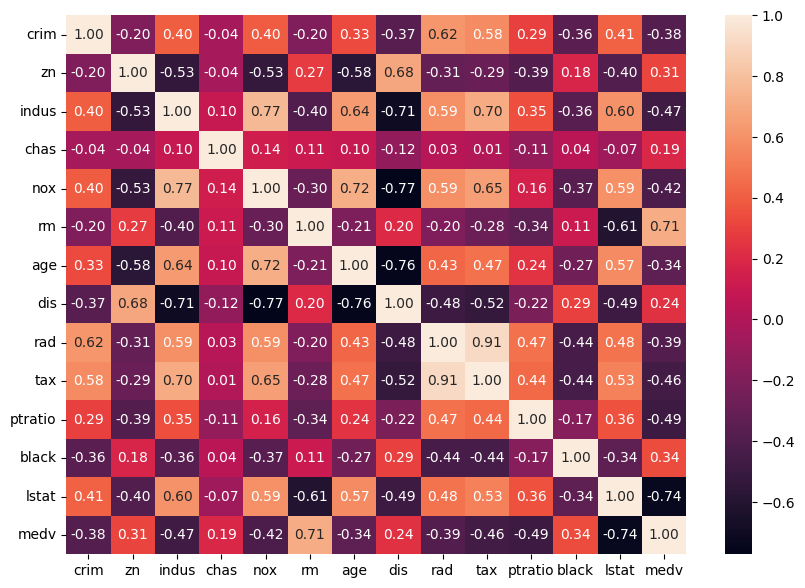

In [ ]:
# Heatmap correlation
data_train = pd.concat([feature_data_train, target_data_train], axis=1)
corr = data_train.corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, fmt='.2f')
plt.show()

The correlation of 'tax' with 'medv' (-0.46) is higher than the correlation of 'rad' with 'medv' (-0.39),

so the 'rad' column can be dropped

In [ ]:
# Drop redundant feature
feature_data_train = feature_data_train.drop(columns=['rad'])
feature_data_test = feature_data_test.drop(columns=['rad'])

In [ ]:
# Recheck VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.tools.tools import add_constant

X = add_constant(feature_data_train)

vif_df = pd.DataFrame([vif(X.values, i)
               for i in range(X.shape[1])],
              index=X.columns).reset_index()
vif_df.columns = ['feature','vif_score']
vif_df = vif_df.loc[vif_df.feature!='const']
vif_df

,feature,vif_score
1,crim,1.593872
2,zn,2.413664
3,indus,3.658237
4,chas,1.084671
5,nox,4.411973
6,rm,1.884987
7,age,2.977080
8,dis,4.166015
9,tax,3.331299
10,ptratio,1.776290


In [ ]:
# Model training
from sklearn.linear_model import Ridge

# train the model
X_data_train = feature_data_train.to_numpy()
y_data_train = target_data_train.to_numpy()
y_data_train = y_data_train.reshape(len(y_data_train),)

# define the model
ridge_reg = Ridge(alpha=0.1,
                  random_state=42)

ridge_reg.fit(X_data_train, y_data_train)

Ridge(alpha=0.1, random_state=42)

In [ ]:
# retrieve the coefficients
# model = ridge_reg

Data = feature_data_train

coef_df = pd.DataFrame({
    'feature':['intercept'] + Data.columns.tolist(),
    'coefficient':[ridge_reg.intercept_] + list(ridge_reg.coef_)
})

coef_df

,feature,coefficient
0,intercept,23.518308
1,crim,-0.081022
2,zn,0.022474
3,indus,-0.019493
4,chas,3.093697
5,nox,-14.404510
6,rm,4.729954
7,age,-0.010476
8,dis,-1.412181
9,tax,0.000750


In [ ]:
# Lasso
from sklearn.linear_model import Lasso

# define the model
lasso_reg = Lasso(alpha=0.1,
                  random_state=42)

lasso_reg.fit(X_data_train, y_data_train)

Lasso(alpha=0.1, random_state=42)

In [ ]:
# retrieve the coefficients
# model = lasso_reg

Data = feature_data_train

coef_df = pd.DataFrame({
    'feature':['intercept'] + Data.columns.tolist(),
    'coefficient':[lasso_reg.intercept_] + list(lasso_reg.coef_)
})

coef_df

,feature,coefficient
0,intercept,15.425577
1,crim,-0.075710
2,zn,0.027093
3,indus,-0.061336
4,chas,1.266833
5,nox,-0.000000
6,rm,4.564419
7,age,-0.016919
8,dis,-1.155550
9,tax,-0.002088


In [ ]:
# Workflow with choosing the best lambda
# Split train test
from sklearn.model_selection import train_test_split

feature = data.drop(columns='medv')
target = data[['medv']]

# First splitting: pretrain and test
feature_data_pretrain, feature_data_test, target_data_pretrain, target_data_test = train_test_split(feature,
                                                                                                    target, test_size=0.20,
                                                                                                    random_state=42)

# Second splitting: train and validation
feature_data_train, feature_data_validation, target_data_train, target_data_validation = train_test_split(feature_data_pretrain,
                                                                                                          target_data_pretrain,
                                                                                                          test_size=0.20,
                                                                                                          random_state=42)

In [ ]:
# Drop Multicolinear Features
feature_data_train = feature_data_train.drop(columns=['rad'])
feature_data_validation = feature_data_validation.drop(columns=['rad'])
feature_data_test = feature_data_test.drop(columns=['rad'])

In [ ]:
# Train multiple models with different alpha/lambda
# Ridge
from sklearn.linear_model import Ridge

# Train the model
X_data_train = feature_data_train.to_numpy()
y_data_train = target_data_train.to_numpy()
y_data_train = y_data_train.reshape(len(y_data_train),)

# Train model with Alphas (0.01, 0.1, 1, 10
ridge_reg_pointzeroone = Ridge(alpha=0.01, random_state=42)
ridge_reg_pointone = Ridge(alpha=0.1, random_state=42)
ridge_reg_one = Ridge(alpha=1, random_state=42)
ridge_reg_ten = Ridge(alpha=10, random_state=42)

# fit the model (training)
ridge_reg_pointzeroone.fit(X_data_train, y_data_train)
ridge_reg_pointone.fit(X_data_train, y_data_train)
ridge_reg_one.fit(X_data_train, y_data_train)
ridge_reg_ten.fit(X_data_train, y_data_train)

Ridge(alpha=10, random_state=42)

In [ ]:
# Find the best model by validation
# Ridge
from sklearn.metrics import mean_squared_error

X_data_validation = feature_data_validation.to_numpy()
y_data_validation = target_data_validation.to_numpy()
y_data_validation = y_data_validation.reshape(len(y_data_validation),)

alphas = [0.01, 0.1, 1., 10]
models = [ridge_reg_pointzeroone,
          ridge_reg_pointone,
          ridge_reg_one,
          ridge_reg_ten]

for model, alpha in zip(models, alphas):
    y_predict_validation = model.predict(X_data_validation)
    rmse = np.sqrt(mean_squared_error(y_data_validation,y_predict_validation))
    print(f'RMSE of Ridge regression model with alpha = {alpha} is {rmse}')

RMSE of Ridge regression model with alpha = 0.01 is 4.960676932957843
RMSE of Ridge regression model with alpha = 0.1 is 4.94941253512279
RMSE of Ridge regression model with alpha = 1.0 is 4.912351371579992
RMSE of Ridge regression model with alpha = 10 is 4.871717983886228


The smallest RMSE by Ridge regression is found at alpha 10, with an RMSE of 4.871717983886228

In [ ]:
# Coefficient by Ridge
ridge_best = ridge_reg_ten

coef_df = pd.DataFrame({
    'feature':['intercept'] + feature_data_train.columns.tolist(),
    'coefficient':[ridge_best.intercept_] + list(ridge_best.coef_)
})

coef_df

,feature,coefficient
0,intercept,15.064666
1,crim,-0.071408
2,zn,0.033030
3,indus,-0.067858
4,chas,1.955801
5,nox,-1.568248
6,rm,4.783168
7,age,-0.011523
8,dis,-1.260056
9,tax,-0.001976


MEDV = 15.0647 − 0.0714 crim +0.0330 zn − 0.0679  indus +1.9558 chas − 1.5682 nox + 4.7832 rm - 0.0115 age − 1.2601 dis − 0.0020 tax − 0.6976 ptratio + 0.0127 black − 0.5238 lstat

**Interpretation**

Harga rumah rata-rata di Boston dimulai dari harga $15.0647. Harga ini dapat naik dan turun bergantung dengan hal-hal sebagai berikut:

1. Tingkat kriminalitas (crim) → bobot = -0.071

Makna: Semakin tinggi tingkat kriminalitas, semakin rendah harga rumah

Penjelasan: Jika crim naik 1 unit, harga rumah turun sekitar $0.071

2. Presentase area rumah besar (zn) → bobot = +0.033

Makna: Daerah dengan kawasan rumah besar cenderung memiliki harga rumah yang lebih tinggi

Penjelasan: Setiap kenaikan 1 unit zn, harga rumah naik sekitar $0.033

3. Luas area industri (indus) → bobot = -0.068

Makna: Semakin banyak area industri, harga rumah semakin turun

Penjelasan: Jika indus naik 1 unit, harga rumah turun sekitar $0.068

4. Dekat Sungai Charles (chas) → bobot = +1.956

Makna: Rumah yang berada dekat sungai memiliki harga yang lebih mahal

Penjelasan: Jika chas = 1, harga rumah naik sekitar $1.956

5. Polusi NOx (nox) → bobot = -1.568

Makna: Polusi tinggi menurunkan harga rumah

Penjelasan: Setiap kenaikan 1 unit nox, harga rumah turun sekitar $1.568

6. Jumlah rata-rata kamar (rm) → bobot = +4.783

Makna: Rumah dengan lebih banyak kamar memiliki harga jauh lebih tinggi

Penjelasan: Jika jumlah kamar bertambah 1 unit, harga rumah naik sekitar $4.783

7. Proporsi rumah tua (age) → bobot = -0.0115

Makna: Lingkungan yang lebih tua cenderung memiliki harga rumah sedikit lebih rendah

Penjelasan: Jika age naik 1 unit, harga rumah turun sekitar $0.0115

8. Jarak ke pusat kota (dis) → bobot = -1.260

Makna: Semakin jauh dari pusat kota, harga rumah semakin murah

Penjelasan: Jika dis naik 1 unit, harga rumah turun sekitar $1.260

9. Tarif pajak (tax) → bobot = -0.0020

Makna: Pajak yang tinggi menurunkan minat pembelian sehingga harga rumah lebih rendah

Penjelasan: Jika pajak naik 1 unit, harga rumah turun $0.002

10. Rasio murid-guru (ptratio) → bobot = -0.697

Makna: Semakin buruk kualitas sekolah (lebih banyak murid per guru), harga rumah makin rendah

Penjelasan: Jika ptratio naik 1 unit, harga rumah turun sekitar $0.697

11. Proporsi populasi black (black) → bobot = +0.0127

Makna: Wilayah dengan nilai indeks black yang lebih tinggi sedikit meningkatkan harga rumah

Penjelasan: Jika black naik 1 unit, harga rumah naik sekitar $0.0127

12. Persentase status sosial rendah (lstat) → bobot = -0.524

Makna: Semakin banyak penduduk berstatus ekonomi rendah, harga rumah semakin turun

Penjelasan: Jika lstat naik 1 unit, harga rumah turun sekitar $0.524

In [ ]:
# Evaluation data train (Ridge)
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error

y_predict_train_ridge = ridge_best.predict(X_data_train)

print('Ridge MAE for training data is {}'.format(mean_absolute_error(y_data_train, y_predict_train_ridge)))
print('Ridge RMSE for training data is {}'.format(root_mean_squared_error(y_data_train, y_predict_train_ridge)))
print('Ridge MAPE for training data is {}'.format(mean_absolute_percentage_error(y_data_train, y_predict_train_ridge)*100))
print('Ridge R2 for training data is {}'.format(r2_score(y_data_train, y_predict_train_ridge)*100))

Ridge MAE for training data is 3.3776762058865626
Ridge RMSE for training data is 4.77864036104011
Ridge MAPE for training data is 16.8680736633595
Ridge R2 for training data is 74.85875263669821


In [ ]:
# Evaluation data test (Ridge)
# prepare prediction result on test data
X_data_test_ridge = feature_data_test.to_numpy()
y_predict_test_ridge = ridge_best.predict(X_data_test_ridge)


# ground truth target
y_data_test_ridge = target_data_test.to_numpy()
y_data_test_ridge = y_data_test_ridge.reshape(len(y_data_test_ridge),)

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

print('Ridge RMSE for testing data is {}'.format(np.sqrt(mean_squared_error(y_data_test_ridge, y_predict_test_ridge))))
print('Ridge MAE for testing data is {}'.format(mean_absolute_error(y_data_test_ridge, y_predict_test_ridge)))
print('Ridge MAPE for testing data is {}'.format(mean_absolute_percentage_error(y_data_test_ridge, y_predict_test_ridge)))
print('Ridge R2 for training data is {}'.format(r2_score(y_predict_test_ridge, y_data_test_ridge)*100))

Ridge RMSE for testing data is 5.158908333657057
Ridge MAE for testing data is 3.244481645704498
Ridge MAPE for testing data is 0.17618402626767926
Ridge R2 for training data is 58.13300262902785


**Berdasarkan data train dan test Ridge**

**MAE:**

Data training dengan nilai MAE 3.378
Rata-rata prediksi model melenceng sekitar $3.378 ribu dari harga rumah sebenarnya di data pelatihan

Data testing dengan nilai MAE 3.244
Rata-rata prediksi model melenceng sekitar $3.244 ribu di data baru

Model Ridge dapat memprediksi harga rumah dengan error sedikit lebih rendah di data testing dibanding training, menunjukkan model stabil

**RMSE:**

- 4.779 (train) vs 5.159 (test)

Model Ridge memiliki error besar sedikit meningkat di test dibanding train, namun masih tergolong stabil

**MAPE:**

- 16.87% (train) vs 17.62% (test)

Model Ridge rata-rata melenceng sekitar 17% dari harga rumah sebenarnya, menunjukkan prediksi yang cukup konsisten dan stabil antara training dan testing

**R²:**

- 74.86% (train) vs 58.13% (test)

Model Ridge mampu menjelaskan sekitar 74,9% variasi harga rumah di data training dan 58,1% di data testing. Dari data ini terlihat penurunan performa di test set, namun model tetap cukup baik

In [ ]:
# Train multiple models with different alpha/lambda
# Lasso
from sklearn.linear_model import Lasso

# Train the model
X_data_train = feature_data_train.to_numpy()
y_data_train = target_data_train.to_numpy()
y_data_train = y_data_train.reshape(len(y_data_train),)

# Train model with Alphas (0.01, 0.1, 1, 10
Lasso_reg_pointzeroone = Lasso(alpha=0.01, random_state=42)
Lasso_reg_pointone = Lasso(alpha=0.1, random_state=42)
Lasso_reg_one = Lasso(alpha=1, random_state=42)
Lasso_reg_ten = Lasso(alpha=10, random_state=42)

# fit the model (training)
Lasso_reg_pointzeroone.fit(X_data_train, y_data_train)
Lasso_reg_pointone.fit(X_data_train, y_data_train)
Lasso_reg_one.fit(X_data_train, y_data_train)
Lasso_reg_ten.fit(X_data_train, y_data_train)

Lasso(alpha=10, random_state=42)

In [ ]:
# Find the best model by validation
# Lasso
from sklearn.metrics import mean_squared_error

X_data_validation = feature_data_validation.to_numpy()
y_data_validation = target_data_validation.to_numpy()
y_data_validation = y_data_validation.reshape(len(y_data_validation),)

alphas = [0.01, 0.1, 1., 10]
models = [Lasso_reg_pointzeroone,
          Lasso_reg_pointone,
          Lasso_reg_one,
          Lasso_reg_ten]

for model, alpha in zip(models, alphas):
    y_predict_validation = model.predict(X_data_validation)
    rmse = np.sqrt(mean_squared_error(y_data_validation,y_predict_validation))
    print(f'RMSE of Lasso regression model with alpha = {alpha} is {rmse}')

RMSE of Lasso regression model with alpha = 0.01 is 4.934105658639752
RMSE of Lasso regression model with alpha = 0.1 is 4.907145314259478
RMSE of Lasso regression model with alpha = 1.0 is 4.845855910636398
RMSE of Lasso regression model with alpha = 10 is 5.426622694252769


The smallest RMSE by Lasso regression is found at alpha 1, with an RMSE of 4.845855910636398

In [ ]:
# Coefficient by Lasso
Lasso_best = Lasso_reg_one

coef_df = pd.DataFrame({
    'feature':['intercept'] + feature_data_train.columns.tolist(),
    'coefficient':[Lasso_best.intercept_] + list(Lasso_best.coef_)
})

coef_df

,feature,coefficient
0,intercept,25.823435
1,crim,-0.041076
2,zn,0.025273
3,indus,-0.000000
4,chas,0.000000
5,nox,-0.000000
6,rm,2.504122
7,age,0.022055
8,dis,-0.599362
9,tax,-0.002994


medv = 25.823 - 0.041 crim + 0.025 zn + 2.504 rm + 0.022 age - 0.599 dis - 0.003 tax - 0.666 ptratio + 0.011 black - 0.712 lstat

**Interpretasi**

Harga rumah rata-rata di Boston dimulai dari harga $25.823. Harga ini dapat naik dan turun bergantung dengan hal-hal sebagai berikut:

1. Tingkat kriminalitas (crim) -> bobot = -0.041

Makna = semakin tinggi tingkat kriminalitas, semakin rendah harga rumah

Penjelasan = Jika nilai crim naik 1 unit, maka harga rumah akan turun $ 0.041

2. Presentase area rumah besar (zn) -> bobot = +0.025

Makna = Daerah yang memiliki kawasan dengan banyak rumah besar maka harga rumah akan lebih tinggi

Penjelasan = Setiap naiknya persentase area rumah besar maka harga rumah akan naik $0.025

3. Jumlah rata-rata kamar (rm) -> bobot = +2.504

Makna: Rumah dengan lebih banyak kamar harganya jauh lebih mahal

Penjelasan: Setiap tambahan 1 kamar, harga rumah naik sekitar $2.504

4. Proporsi rumah tua (age) -> bobit = +0.022

Makna: Semakin tua lingkungannya, harga sedikit meningkat

Penjelasan: Jika age naik 1 unit, harga rumah naik sekitar $0.022

5. Jarak ke pusat kota (dis) → bobot = -0.599

Makna: Semakin jauh dari pusat kota, harga semakin murah

Penjelasan: Setiap kenaikan 1 unit distance, harga rumah turun sekitar $0.599

6. Tarif pajak (tax) → bobot = –0.003

Makna: Pajak tinggi membuat harga rumah lebih rendah

Penjelasan: Jika tarif pajak naik 1 unit, harga rumah turun sekitar $0.003

7. Rasio murid-guru (ptratio) → bobot = –0.666

Makna: Semakin buruk kualitas sekolah (murid lebih banyak per guru), harga rumah lebih murah

Penjelasan: Jika ptratio naik 1 unit, harga rumah turun sekitar $0.666

8. Proporsi populasi black (black) → bobot = +0.011

Makna: Komunitas dengan nilai indeks black lebih tinggi sedikit menaikkan harga rumah

Penjelasan: Jika black naik 1 unit, harga rumah naik sekitar $0.011

9. Persentase status sosial rendah (lstat) → bobot = –0.712

Makna: Semakin banyak penduduk berstatus ekonomi rendah, harga rumah makin murah

Penjelasan: Jika lstat naik 1 unit, harga rumah turun sekitar $0.712


In [ ]:
# Evaluation data train (Lasso)
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error

y_predict_train_lasso = Lasso_best.predict(X_data_train)

print('Lasso MAE for training data is {}'.format(mean_absolute_error(y_data_train, y_predict_train_lasso)))
print('Lasso RMSE for training data is {}'.format(root_mean_squared_error(y_data_train, y_predict_train_lasso)))
print('Lasso MAPE for training data is {}'.format(mean_absolute_percentage_error(y_data_train, y_predict_train_lasso)*100))
print('Lasso R2 for training data is {}'.format(r2_score(y_data_train, y_predict_train_lasso)*100))

Lasso MAE for training data is 3.6858416211465084
Lasso RMSE for training data is 5.170346463296143
Lasso MAPE for training data is 17.49128202363825
Lasso R2 for training data is 70.56815963218594


In [ ]:
# Evaluation data test (Lasso)

# Prepare prediction result on test data
X_data_test_lasso = feature_data_test.to_numpy()
y_predict_test_lasso = Lasso_best.predict(X_data_test_lasso)

# Ground truth target
y_data_test_lasso = target_data_test.to_numpy()
y_data_test_lasso = y_data_test_lasso.reshape(len(y_data_test_lasso),)

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import r2_score
import numpy as np

print('Lasso RMSE for testing data is {}'.format(np.sqrt(mean_squared_error(y_data_test_lasso, y_predict_test_lasso))))
print('Lasso MAE for testing data is {}'.format(mean_absolute_error(y_data_test_lasso, y_predict_test_lasso)))
print('Lasso MAPE for testing data is {}'.format(mean_absolute_percentage_error(y_data_test_lasso, y_predict_test_lasso)* 100))
print('Lasso R2 for testing data is {}'.format(r2_score(y_data_test_lasso, y_predict_test_lasso) * 100))

Lasso RMSE for testing data is 5.125494212319777
Lasso MAE for testing data is 3.3980507105960682
Lasso MAPE for testing data is 17.856606338732206
Lasso R2 for testing data is 64.17655030412067


**Berdasarkan data train dan test lasso**

**MAE:**
- data training dengan nilai MAE 3.686
Rata-rata prediksi model melenceng sekitar $3.686 ribu dari harga rumah sebenarnya di data pelatihan

- data training dengan nilai MAE 3.398
Rata-rata prediksi model melenceng sekitar $3.398 ribu di data baru

Model lasso dapat mempredikasi harga rumah dengan error lebih rendah dari training data yaitu $3.4 ribu


**RMSE:**
- 5.17 (train) vs 5.13 (test)

Model lasso memiliki error besar hampir sama di train dan test, sehingga dapat menandakan model cukup stabil

**MAPE:**
- 17.49% (train) vs 17.85% (test)

Model Lasso rata-rata melenceng sekitar 17–18% dari harga rumah sebenarnya yang menunjukkan prediksi yang cukup konsisten dan stabil antara training dan testing

**R²:**
- 70.6% (train) vs 64.2% (test)
Model Lasso mampu menjelaskan sekitar 70,6% variasi harga rumah di data training dan 64,2% di data testing. Dari data ini dapat dilihat sedikit penurunan di test set

Berdasarkan hasil data ridge dan lasso dapat dilihat bahwa keduanya dapat memprediksi harga rumah

Namun, untuk Lasso dapat memprediksi data baru/testing lebih baik dari ridge sehingga Lasso lebih baik untuk memprediksi harga yang belum pernah dilihat.

Hal ini dapat dilihat dari nilai R2 (R-squared) yaitu untuk mengukur seberapa baik model dalam memprediksi data

Berdasarkan data dapat dilihat R2 yaitu:
Ridge test = 58.13%
Lasso test = 64.18%

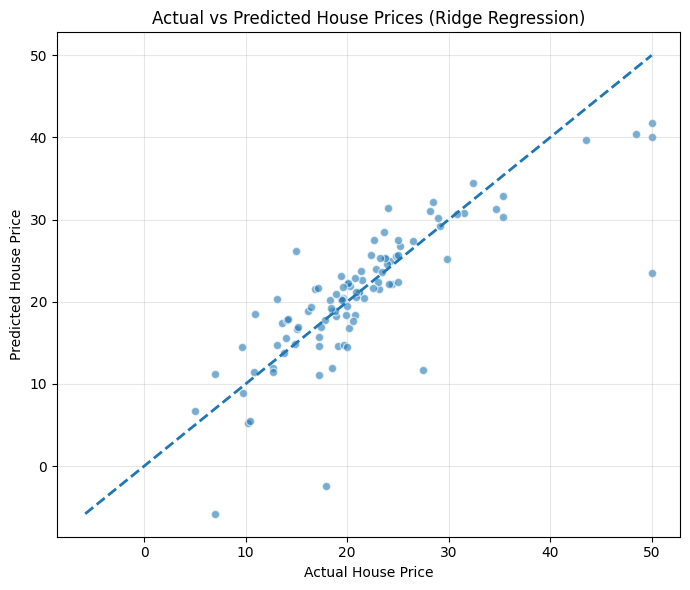

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# pastikan ini sudah ada
y_true = y_data_test_ridge
y_pred = y_predict_test_ridge

plt.figure(figsize=(7, 6))

plt.scatter(
    y_true,
    y_pred,
    alpha=0.6,
    edgecolor="white"
)

# garis ideal y = x
max_val = max(y_true.max(), y_pred.max())
min_val = min(y_true.min(), y_pred.min())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices (Ridge Regression)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


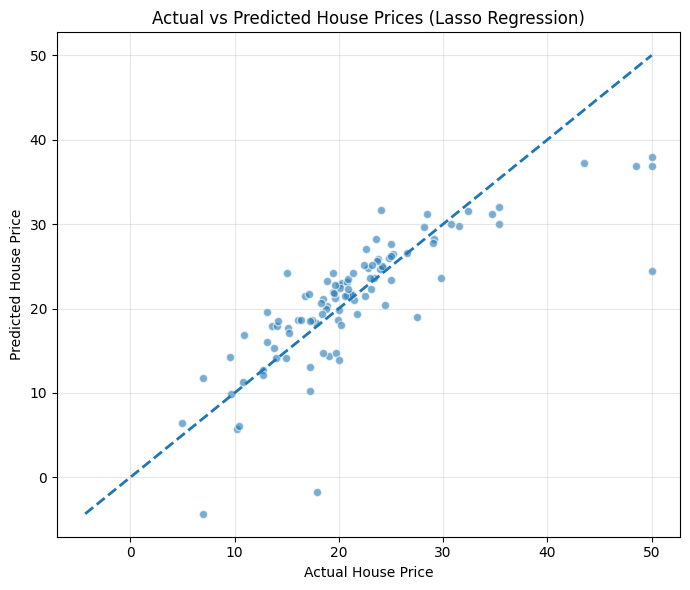

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# actual & predicted (lasso)
y_true = y_data_test_lasso
y_pred = y_predict_test_lasso

plt.figure(figsize=(7, 6))

plt.scatter(
    y_true,
    y_pred,
    alpha=0.6,
    edgecolor="white"
)

# perfect prediction line
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices (Lasso Regression)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
